In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# 1. Load and prepare data
df = pd.read_excel('../data/Dry_Bean_Dataset.xlsx', sheet_name='Dry_Beans_Dataset')
X = df.iloc[:, 0:16].values
y = df['Class'].values

# Encode labels (7 classes)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

# Split data: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y_encoded, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [49]:
# 2. Define logistic regression model (no create_model function needed, as it's simple)
# We'll use it directly in loops

# Hyperparameters
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]  # For regularization tuning (inverse of reg strength)
max_iter_base = 100  # Base iterations

In [50]:
# 3. Train the model (no loss history, but we'll evaluate accuracies)
# For LR, no epoch-wise loss, so skip plotting cost, or note it

In [51]:
# 4. Hyperparameter regularization (tune C for regularization)
print('\nHyperparameter Tuning for Regularization (C):')
reg_results = {}

for C in C_values:
    print(f'Training with C={C}')
    model = LogisticRegression(solver='lbfgs', C=C, max_iter=10000, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    # Evaluate on validation set
    y_val_pred = model.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    reg_results[C] = val_acc
    print(f'C {C}: Validation Accuracy {val_acc:.4f}')

# Select best C (lowest regularization is highest C, but based on acc)
best_C = max(reg_results, key=reg_results.get)
print(f'Best C: {best_C} with Val Acc: {reg_results[best_C]:.4f}')


Hyperparameter Tuning for Regularization (C):
Training with C=0.001
C 0.001: Validation Accuracy 0.8972
Training with C=0.01
C 0.01: Validation Accuracy 0.9207
Training with C=0.1
C 0.1: Validation Accuracy 0.9246
Training with C=1.0
C 1.0: Validation Accuracy 0.9246
Training with C=10.0
C 10.0: Validation Accuracy 0.9241
Training with C=100.0
C 100.0: Validation Accuracy 0.9251
Best C: 100.0 with Val Acc: 0.9251


In [52]:
# Retrain with best C
model = LogisticRegression(solver='lbfgs', C=best_C, max_iter=10000, random_state=42)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,100.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [53]:
# 5. Evaluate accuracy for different number of iterations (max_iter)
print('\nValidation Accuracy at Different Max Iterations:')
iter_values = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]  # Increased starting value to avoid convergence issues
iter_accuracies = []

for max_iter in iter_values:
    temp_model = LogisticRegression(solver='lbfgs', C=best_C, max_iter=max_iter, random_state=42)
    temp_model.fit(X_train_scaled, y_train)
    y_val_pred = temp_model.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    iter_accuracies.append(val_acc)
    print(f'At max_iter {max_iter}: {val_acc:.4f}')


Validation Accuracy at Different Max Iterations:
At max_iter 1000: 0.9251
At max_iter 2000: 0.9251
At max_iter 3000: 0.9251
At max_iter 4000: 0.9251
At max_iter 5000: 0.9251
At max_iter 6000: 0.9251
At max_iter 7000: 0.9251
At max_iter 8000: 0.9251
At max_iter 9000: 0.9251
At max_iter 10000: 0.9251


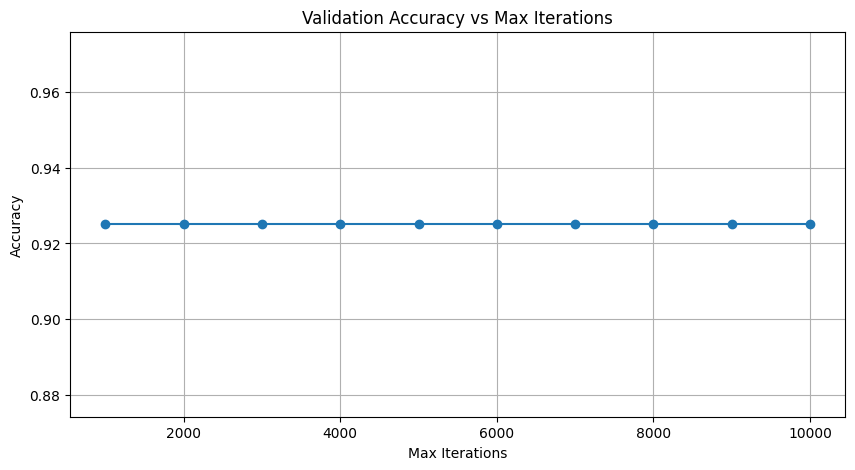

In [54]:
# Plot accuracies vs max_iter
plt.figure(figsize=(10, 5))
plt.plot(iter_values, iter_accuracies, marker='o')
plt.title('Validation Accuracy vs Max Iterations')
plt.xlabel('Max Iterations')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [55]:
# Final test accuracy
y_test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_test_pred)
print(f'\nFinal Test Accuracy: {test_acc:.4f}')


Final Test Accuracy: 0.9212


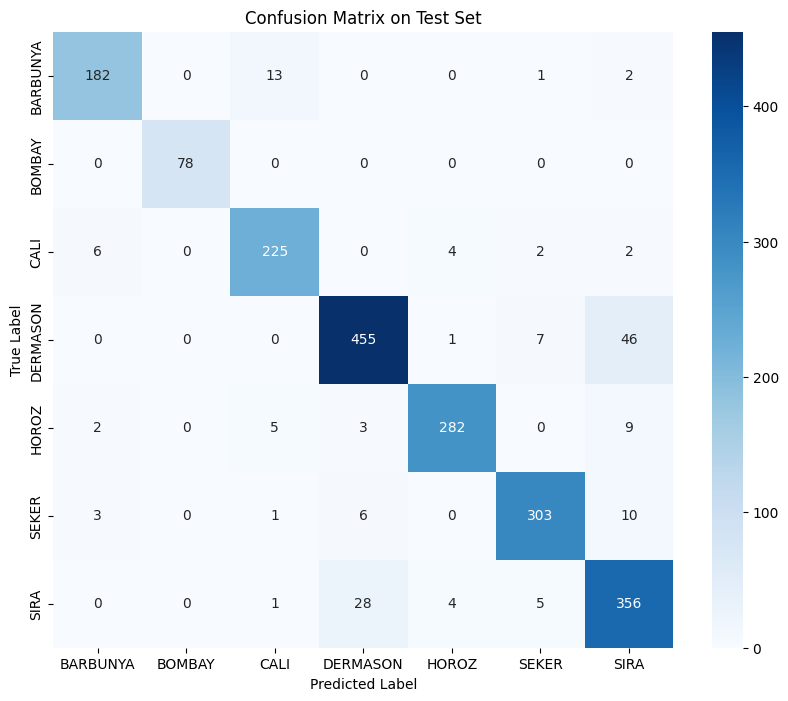

In [56]:
# 6. Plot confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [57]:
# 7. Classification Report
print('\nClassification Report on Test Set:')
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))


Classification Report on Test Set:
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.92      0.93       198
      BOMBAY       1.00      1.00      1.00        78
        CALI       0.92      0.94      0.93       239
    DERMASON       0.92      0.89      0.91       509
       HOROZ       0.97      0.94      0.95       301
       SEKER       0.95      0.94      0.95       323
        SIRA       0.84      0.90      0.87       394

    accuracy                           0.92      2042
   macro avg       0.94      0.93      0.93      2042
weighted avg       0.92      0.92      0.92      2042

